In [1]:
!unzip imagewoof200.zip

Archive:  imagewoof200.zip
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00003690.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00009052.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00011152.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00012460.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00017380.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00019830.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00022292.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00025912.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00027492.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00028540.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00029381.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00029691.JPEG  
 

In [2]:
from pathlib import Path
data_path = Path("")
image_path = data_path / "imagewoof200"

In [3]:
import os
def check_data(dir_path):
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"# of directories {len(dirnames)} and {len(filenames)} images in '{dirpath}'.")

In [4]:
check_data(image_path)

# of directories 2 and 0 images in 'imagewoof200'.
# of directories 10 and 0 images in 'imagewoof200/test'.
# of directories 0 and 48 images in 'imagewoof200/test/samoyed'.
# of directories 0 and 48 images in 'imagewoof200/test/dingo'.
# of directories 0 and 48 images in 'imagewoof200/test/english_foxhound'.
# of directories 0 and 48 images in 'imagewoof200/test/golden_retriever'.
# of directories 0 and 48 images in 'imagewoof200/test/border_terrier'.
# of directories 0 and 48 images in 'imagewoof200/test/rhodesian_ridgeback'.
# of directories 0 and 48 images in 'imagewoof200/test/shih_tzu'.
# of directories 0 and 48 images in 'imagewoof200/test/beagle'.
# of directories 0 and 48 images in 'imagewoof200/test/old_english_sheepdog'.
# of directories 0 and 48 images in 'imagewoof200/test/australian_terrier'.
# of directories 10 and 0 images in 'imagewoof200/train'.
# of directories 0 and 200 images in 'imagewoof200/train/samoyed'.
# of directories 0 and 200 images in 'imagewoof200/train/d

In [5]:
train_dir = image_path / "train"
test_dir = image_path / "test"

In [6]:
train_dir

PosixPath('imagewoof200/train')

In [8]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [9]:
NUM_WORKERS = os.cpu_count()

def create_dataloaders(
    train_dir: str,
    test_dir: str,
    transform: transforms.Compose,
    batch_size: int,
    num_workers: int = NUM_WORKERS
):
  train_data = datasets.ImageFolder(train_dir, transform=transform)
  test_data = datasets.ImageFolder(train_dir, transform=transform)

  class_names = train_data.classes

  train_dataloader = DataLoader(
      dataset = train_data,
      batch_size = batch_size,
      shuffle = True,
      num_workers=num_workers,
      pin_memory=True)
  test_dataloader = DataLoader(
      dataset = test_data,
      batch_size = batch_size,
      shuffle = False,
      num_workers=num_workers,
      pin_memory=True
    )

  return train_dataloader, test_dataloader, class_names



In [10]:
import torchvision

In [11]:
weights = torchvision.models.GoogLeNet_Weights.DEFAULT

In [12]:
weights

GoogLeNet_Weights.IMAGENET1K_V1

In [13]:
auto_transforms = weights.transforms()

In [14]:
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [15]:
train_dataloader, test_dataloader, class_names = create_dataloaders(train_dir=train_dir,
                                                                    test_dir = test_dir,
                                                                    transform = auto_transforms,
                                                                    batch_size = 32)

In [16]:
import torch
torch.cuda.is_available()

True

In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [18]:
device

'cuda'

In [19]:
model = torchvision.models.googlenet(weights = weights).to(device)

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 120MB/s]


In [20]:
model

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [21]:
!pip install torchinfo

In [22]:
from torchinfo import summary

In [24]:
summary(model = model, input_size= (32,3,224,224), col_names = ["input_size", "output_size", "num_params", "trainable"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
GoogLeNet                                [32, 3, 224, 224]         [32, 1000]                --                        True
├─BasicConv2d: 1-1                       [32, 3, 224, 224]         [32, 64, 112, 112]        --                        True
│    └─Conv2d: 2-1                       [32, 3, 224, 224]         [32, 64, 112, 112]        9,408                     True
│    └─BatchNorm2d: 2-2                  [32, 64, 112, 112]        [32, 64, 112, 112]        128                       True
├─MaxPool2d: 1-2                         [32, 64, 112, 112]        [32, 64, 56, 56]          --                        --
├─BasicConv2d: 1-3                       [32, 64, 56, 56]          [32, 64, 56, 56]          --                        True
│    └─Conv2d: 2-3                       [32, 64, 56, 56]          [32, 64, 56, 56]          4,096                     True
│    

In [26]:
import torch.nn as nn

for param in model.parameters():
  param.requires_grad = False

In [27]:
summary(model = model, input_size= (32,3,224,224), col_names = ["input_size", "output_size", "num_params", "trainable"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
GoogLeNet                                [32, 3, 224, 224]         [32, 1000]                --                        False
├─BasicConv2d: 1-1                       [32, 3, 224, 224]         [32, 64, 112, 112]        --                        False
│    └─Conv2d: 2-1                       [32, 3, 224, 224]         [32, 64, 112, 112]        (9,408)                   False
│    └─BatchNorm2d: 2-2                  [32, 64, 112, 112]        [32, 64, 112, 112]        (128)                     False
├─MaxPool2d: 1-2                         [32, 64, 112, 112]        [32, 64, 56, 56]          --                        --
├─BasicConv2d: 1-3                       [32, 64, 56, 56]          [32, 64, 56, 56]          --                        False
│    └─Conv2d: 2-3                       [32, 64, 56, 56]          [32, 64, 56, 56]          (4,096)                   False

In [32]:
output_shape = len(class_names)
model.fc = nn.Linear(in_features = 1024, out_features = output_shape).to(device)

In [33]:
summary(model = model, input_size= (32,3,224,224), col_names = ["input_size", "output_size", "num_params", "trainable"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
GoogLeNet                                [32, 3, 224, 224]         [32, 10]                  --                        Partial
├─BasicConv2d: 1-1                       [32, 3, 224, 224]         [32, 64, 112, 112]        --                        False
│    └─Conv2d: 2-1                       [32, 3, 224, 224]         [32, 64, 112, 112]        (9,408)                   False
│    └─BatchNorm2d: 2-2                  [32, 64, 112, 112]        [32, 64, 112, 112]        (128)                     False
├─MaxPool2d: 1-2                         [32, 64, 112, 112]        [32, 64, 56, 56]          --                        --
├─BasicConv2d: 1-3                       [32, 64, 56, 56]          [32, 64, 56, 56]          --                        False
│    └─Conv2d: 2-3                       [32, 64, 56, 56]          [32, 64, 56, 56]          (4,096)                   Fal

In [35]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [44]:
def train_step(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device
):
  model.train()
  train_loss, train_acc= 0.0,0.0

  for batch, (X,y) in enumerate(dataloader):
    X,y = X.to(device), y.to(device)

    y_pred = model(X)

    loss = loss_fn(y_pred,y)
    train_loss += loss.item()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1),dim =1)
    train_acc += (y_pred_class == y).sum().item() / len(y_pred)

  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)
  return train_loss, train_acc


def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device):
  model.eval()
  test_loss, test_acc = 0.0,0.0

  with torch.inference_mode():
    for batch, (X,y) in enumerate(dataloader):
      X,y = X.to(device), y.to(device)
      test_pred_logits = model(X)

      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()

      test_pred_labels = test_pred_logits.argmax(dim=1)
      test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

def train(model: torch.nn.Module,
            train_dataloader: torch.utils.data.DataLoader,
            test_dataloader: torch.utils.data.DataLoader,
            optimizer: torch.optim.Optimizer,
            device: torch.device,
            loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
            epochs: int = 5):
      results = {
          "train_loss": [],
          "train_acc": [],
          "test_loss": [],
          "test_acc": []
      }

      for epoch in range(epochs):
        train_loss, train_acc = train_step(model = model,
                                           dataloader = train_dataloader,
                                           loss_fn = loss_fn,
                                           optimizer = optimizer,
                                           device = device)
        test_loss, test_acc = test_step(model = model,
                                        dataloader = test_dataloader,
                                        loss_fn = loss_fn,
                                        device = device)

        print(
            f"Epoch: {epoch + 1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        results["train_loss"].append(train_loss.item() if isinstance (train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance (train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance (test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance (test_acc, torch.Tensor) else test_acc)

      return results





In [45]:
results = train(model = model, train_dataloader=train_dataloader, test_dataloader=test_dataloader, optimizer = optimizer, device = device, loss_fn = loss_fn,
                epochs = 10)

Epoch: 1 | train_loss: 0.3787 | train_acc: 0.9082 | test_loss: 0.2929 | test_acc: 0.9261
Epoch: 2 | train_loss: 0.3508 | train_acc: 0.9018 | test_loss: 0.2458 | test_acc: 0.9415
Epoch: 3 | train_loss: 0.3334 | train_acc: 0.9038 | test_loss: 0.2311 | test_acc: 0.9365
Epoch: 4 | train_loss: 0.3067 | train_acc: 0.9102 | test_loss: 0.2148 | test_acc: 0.9464
Epoch: 5 | train_loss: 0.2765 | train_acc: 0.9206 | test_loss: 0.1992 | test_acc: 0.9484
Epoch: 6 | train_loss: 0.2703 | train_acc: 0.9236 | test_loss: 0.1854 | test_acc: 0.9534
Epoch: 7 | train_loss: 0.2662 | train_acc: 0.9177 | test_loss: 0.1693 | test_acc: 0.9568
Epoch: 8 | train_loss: 0.2356 | train_acc: 0.9375 | test_loss: 0.1545 | test_acc: 0.9663
Epoch: 9 | train_loss: 0.2198 | train_acc: 0.9395 | test_loss: 0.1664 | test_acc: 0.9519
Epoch: 10 | train_loss: 0.2163 | train_acc: 0.9395 | test_loss: 0.1408 | test_acc: 0.9683


In [46]:
from PIL import Image

In [47]:
import matplotlib.pyplot as plt

In [48]:
from typing import List, Tuple

In [49]:
def transform_predict(model: torch.nn.Module,
                      image_path: str,
                      class_names: List[str],
                      image_size: Tuple[int,int] = (224,224),
                      transform: torchvision.transforms = None,
                      device: torch.device = device):
  img = Image.open(image_path)
  if transform is not None:
    image_transform = transform
  else:
    image_transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406],std = [0.229, 0.224, 0.225])
    ])

  model.to(device)

  model.eval()
  with torch.inference_mode():
    transformed_image = image_transform(img).unsqueeze(dim = 0)
    target_image_pred = model(transformed_image.to(device))

  target_image_pred_probs = torch.softmax(target_image_pred, dim = 1)
  target_image_pred_label= torch.argmax(target_image_pred_probs, dim =1)

  plt.figure()
  plt.imshow(img)
  plt.title(f"Pred: {class_names[target_image_pred_label]}, Probs: {target_image_pred_probs.max()}")

In [52]:
custom_image_path = data_path / "golden.jpg"

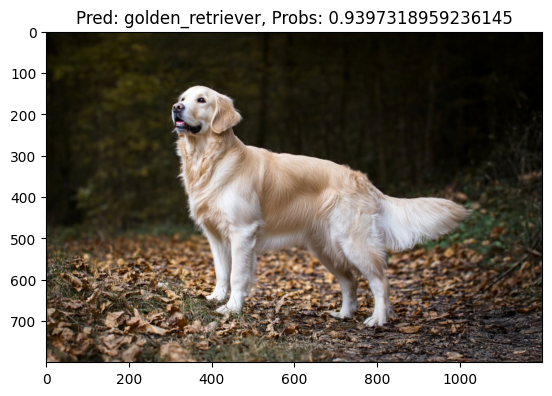

In [53]:
transform_predict(model, custom_image_path, class_names)